In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris(as_frame=True)
df = iris.frame
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df.drop(columns = "target", inplace = True)

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
(150, 5)
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


# Phần 1 - Thống kê mô tả & đặc trưng

### 1. Hiển thị 5 dòng đầu 

In [94]:
display(df.head())
print(f"Bộ dataset iris có {df.shape[0]} dòng và {df.shape[1]} cột")


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Bộ dataset iris có 150 dòng và 5 cột


### 2. Tính mean, median, mode, var, std, min, max, Q1, Q3 và IQR

In [ ]:
# Chọn các cột có dtype là numeric để thực hiện tính toán chỉ số
num_cols = df.select_dtypes(include = "number").columns

# Xây dựng dataframe chứa các chỉ số yêu cầu
desc = pd.DataFrame({
    "mean" : df[num_cols].mean(),
    "median": df[num_cols].median(),
    "mode" : df[num_cols].mode().iloc[0],
    "var" : df[num_cols].var(),
    "std" : df[num_cols].std(),
    "min" : df[num_cols].min(),
    "max": df[num_cols].max(),
    "Q1" : df[num_cols].quantile(0.25),
    "Q3" : df[num_cols].quantile(0.75),
    "IQR" : df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

display(desc)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal length (cm),5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal width (cm),3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal length (cm),3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal width (cm),1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


### 3. Tính mean và std của từng nhóm loài (species)

In [107]:
display(df.groupby("species").agg(["mean", "std"]))

sepal length (cm)           sepal width (cm)            \
                        mean       std             mean       std   
species                                                             
setosa                 5.006  0.352490            3.428  0.379064   
versicolor             5.936  0.516171            2.770  0.313798   
virginica              6.588  0.635880            2.974  0.322497   

           petal length (cm)           petal width (cm)            
                        mean       std             mean       std  
species                                                            
setosa                 1.462  0.173664            0.246  0.105386  
versicolor             4.260  0.469911            1.326  0.197753  
virginica              5.552  0.551895            2.026  0.274650

### Nhận xét

Loài setosa là nhóm thể hiện rõ sự khác biệt nhất so với hai loài còn lại là versicolor và virginica
* K**ích thước cánh hoa nhỏ nhất:** chiều dài trung bình (petal length) chỉ khoảng 1.46 cm (nhỏ hơn lần lượt 3 lần và 4 lần so với versicolor, virginica), chiều rộng trung bình (petal width) là khoảng 0.25 cm (nhỏ hơn lần lượt 5 lần và 8 lần so với versicolor, virginica)

* **Kích thước đài hoa:** setosa có chiều dài đài hoa (sepal length) nhỏ nhất trong cả 3 loài (5 cm so với versicolor: 5.94 cm và virginica; 6.59 cm) và chiều rộng đài hoa lớn nhất (3.43 cm so với virginica: versicolor: 2.78 cm à virginica: 2.97 cm)

* **Về độ lệch chuẩn:** độ lệch chuẩn của kích thước cánh hoa loài setosa rất thấp (0.17 và 0.11). Điều này thể hiện các cá thể thuộc loài hoa này có kích thước cánh hoa đồng đều, ít bị biến động.

# Phần 2 - Phân phối xác suất

### 1. Vẽ histogram và KDE của từng biến

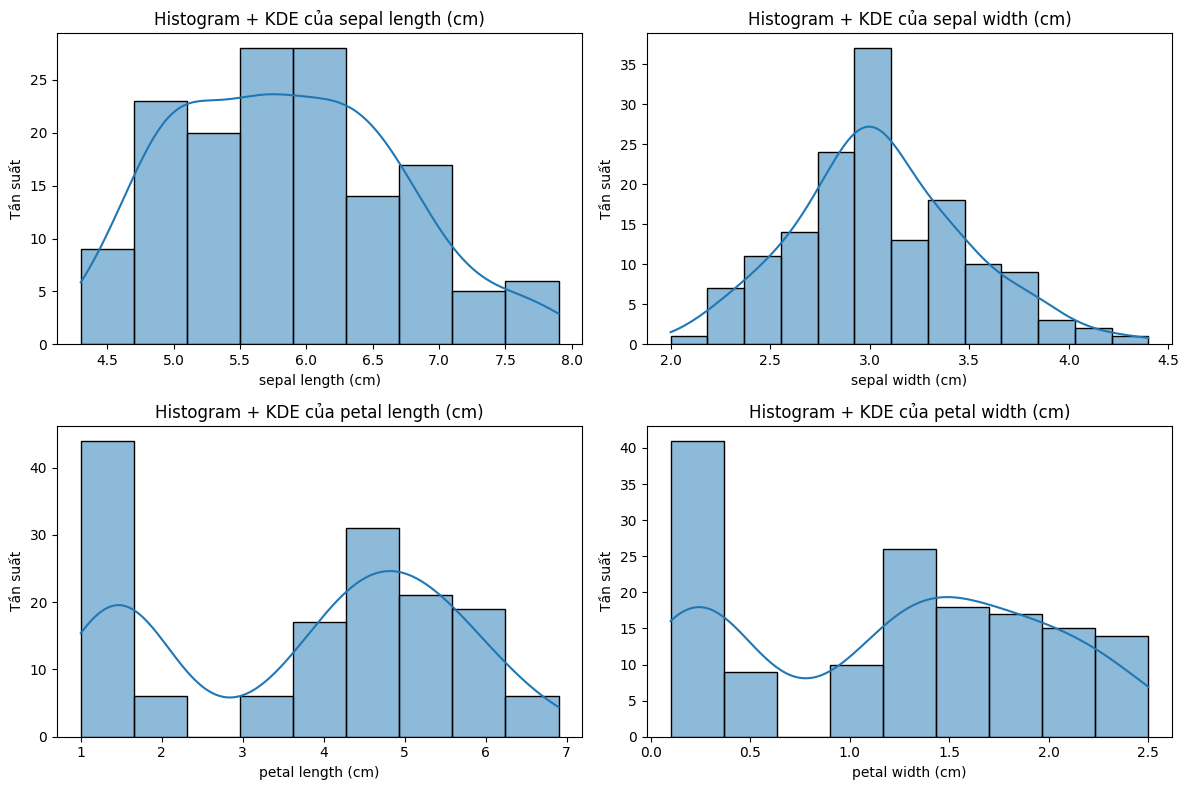

---------Độ lệch (skewness) của từng biến---------
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64 

---------Độ nhọn (kurtosis) của từng biến---------
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64


In [134]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram + KDE của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")
plt.tight_layout()
plt.show()

print("Độ lệch (skewness) của từng biến".center(50,"-"))
print(df[num_cols].skew(),"\n")
print("Độ nhọn (kurtosis) của từng biến".center(50,"-"))
print(df[num_cols].kurt())

### Nhận xét
#### 1. Sepal Length
* **Độ lệch (skewness):** 0.314911

* **Độ nhọn (kurtosis):** -0.552064

**Nhận xét:** Biến sepal length có hình dạng đơn đỉnh, hơi lệch phải (skewness > 0) và phần đỉnh bẹt hơn phân phối chuẩn (kurtosis < 0)

#### 2. Sepal Width
* **Độ lệch (skewness):** 0.318966

* **Độ nhọn (kurtosis):** 0.228249

**Nhận xét:** Biến sepal length có hình dạng đơn đỉnh, hơi lệch phải (skewness > 0) và phần đỉnh nhọn hơn phân phối chuẩn (kurtosis > 0). Tuy nhiên, so sánh trong 4 biến thì sepal width gần phân phối chuẩn nhất (skewness = 0, kurtosis = 0)


#### 3. Petal Length 
* **Độ lệch (skewness):** -0.274884

* **Độ nhọn (kurtosis):** -1.402103

**Nhận xét:** Biến sepal length có phân phối nhiều đỉnh (hai đỉnh), phần đỉnh bẹt hơn phân phối chuẩn (kurtosis < 0)
-0.102967

#### 4. Petal Width
* **Độ lệch (skewness):** -0.102967

* **Độ nhọn (kurtosis):** -1.340604

**Nhận xét:** Biến sepal length có phân phối nhiều đỉnh (hai đỉnh), phần đỉnh bẹt hơn phân phối chuẩn (kurtosis < 0)

### 2. Vẽ boxplot từng biến theo nhóm species

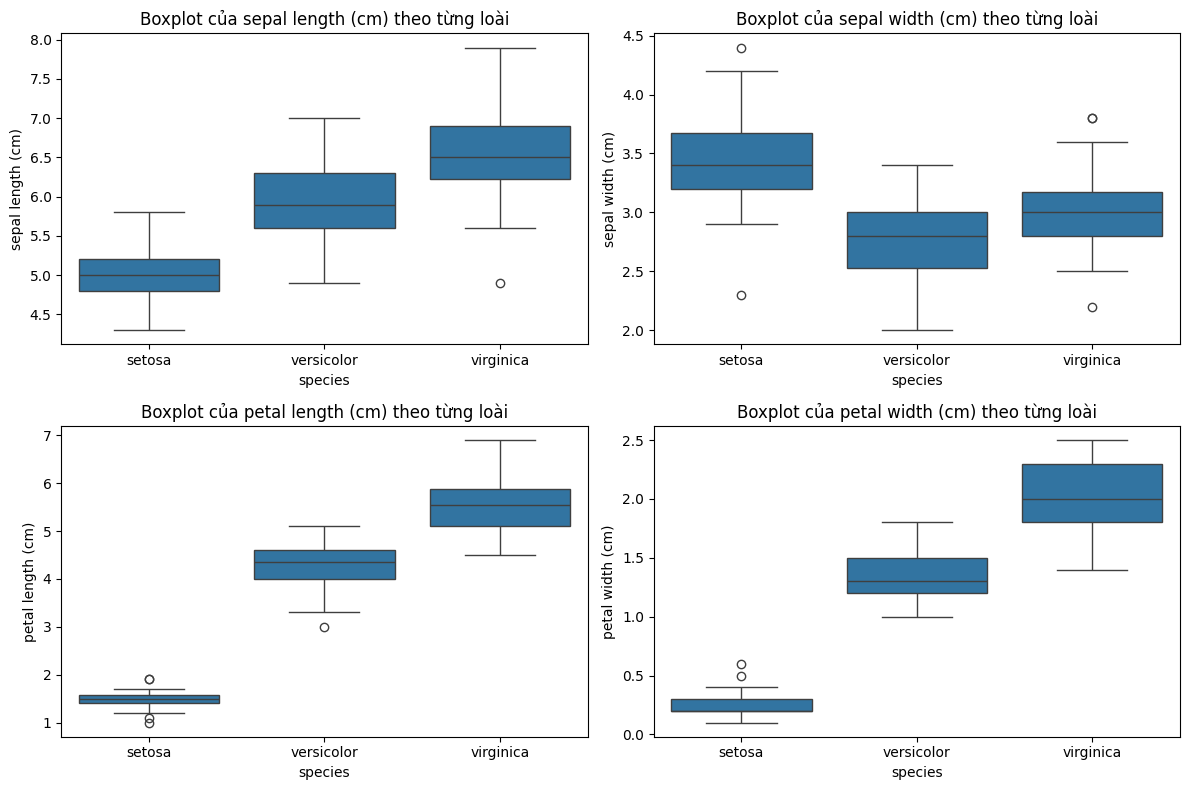

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="species", y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot của {col} theo từng loài")

plt.tight_layout()
plt.show()

### 3. Chọn biến sepal width để mô phỏng

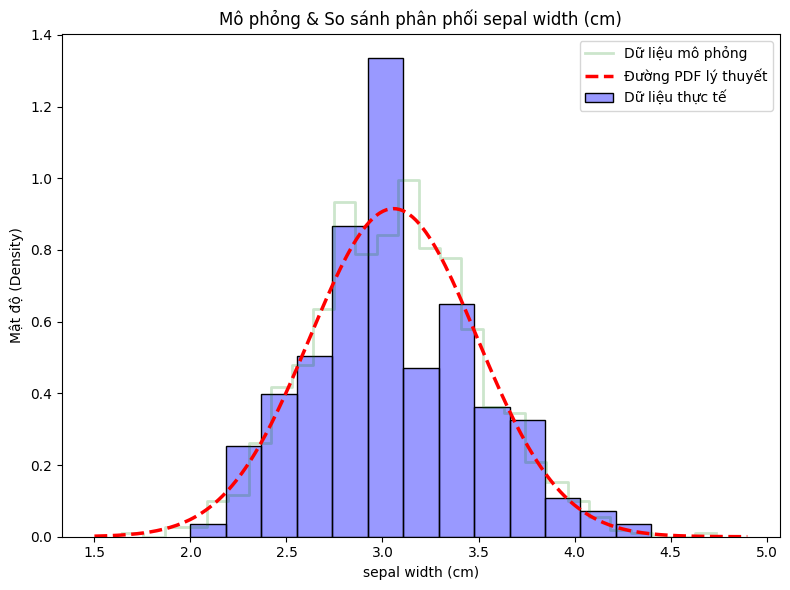

Mean của sepal width: 3.0573333333333337
Std của sepal width: 3.0573333333333337


In [ ]:
var = 'sepal width (cm)'
var_mean = df[var].mean()
var_std = df[var].std()

np.random.seed(42)
simulated_data = np.random.normal(var_mean, var_std, size=1000)

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(df[var], stat='density', alpha=0.4, color='blue', label='Dữ liệu thực tế', ax=ax)
sns.histplot(simulated_data, stat='density', alpha=0.2, color='green', label='Dữ liệu mô phỏng', ax=ax, element='step', fill=False, linewidth=2)

x_axis = np.linspace(df[var].min() - 0.5, df[var].max() + 0.5, 200)
pdf_line = (1 / (var_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - var_mean) / var_std) ** 2)
ax.plot(x_axis, pdf_line, 'r--', lw=2.5, label=f'Đường PDF lý thuyết')

ax.set_title(f'Mô phỏng & So sánh phân phối {var}')
ax.set_xlabel(var)
ax.set_ylabel('Mật độ (Density)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean của sepal width: {var_mean}")
print(f"Std của sepal width: {var_mean}")

### Nhận xét

Biến sepal width có phân phối tương đối gần chuẩn, gần như đối xứng qua đỉnh chuông tại giá trị trung bình là 3 và dốc đều và hai phía

# Phần 3 - Phân tích đa biến & tương quan

### 1. Tính ma trận hiệp phương sai và tương quan 

In [152]:
cov_matrix = df[num_cols].cov()
corr_matrix = df[num_cols].corr()

display(cov_matrix)
display(corr_matrix)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


### 2. Vẽ heatmap tương quan

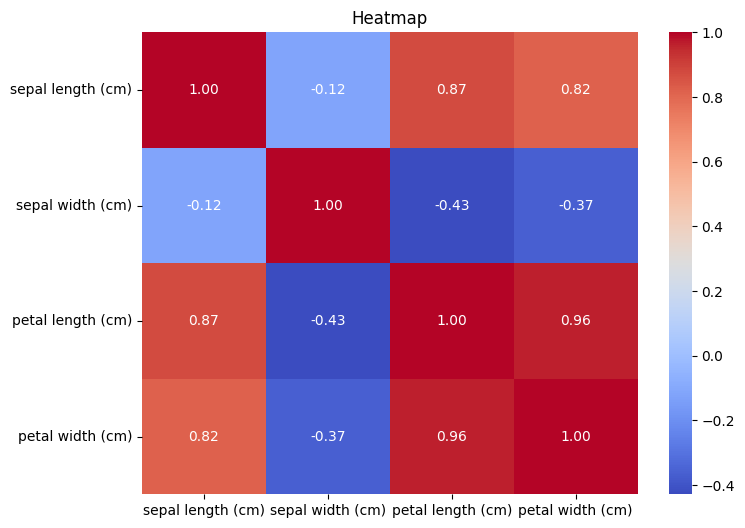

VIF: 13.719272754378562


In [159]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap")
plt.show()

r = df["petal length (cm)"].corr(df["petal width (cm)"])
vif = 1 / (1 - r**2)

print("VIF:", vif)

### Nhận xét

* Cặp biến có tương quan mạnh nhất là petal length và petal width (correlation = 0.96)
  
* Nếu xét theo hệ số tương quan (correlation = 0.96) xấp xỉ 1, có khả năng cao 2 biến này đa cộng tuyến. Để chắc chắn hơn, ta có thể dựa vào chỉ số VIF = 13.72, chứng minh petal length và petal width đa côngj tuyến mạnh

### 3. Pairplot

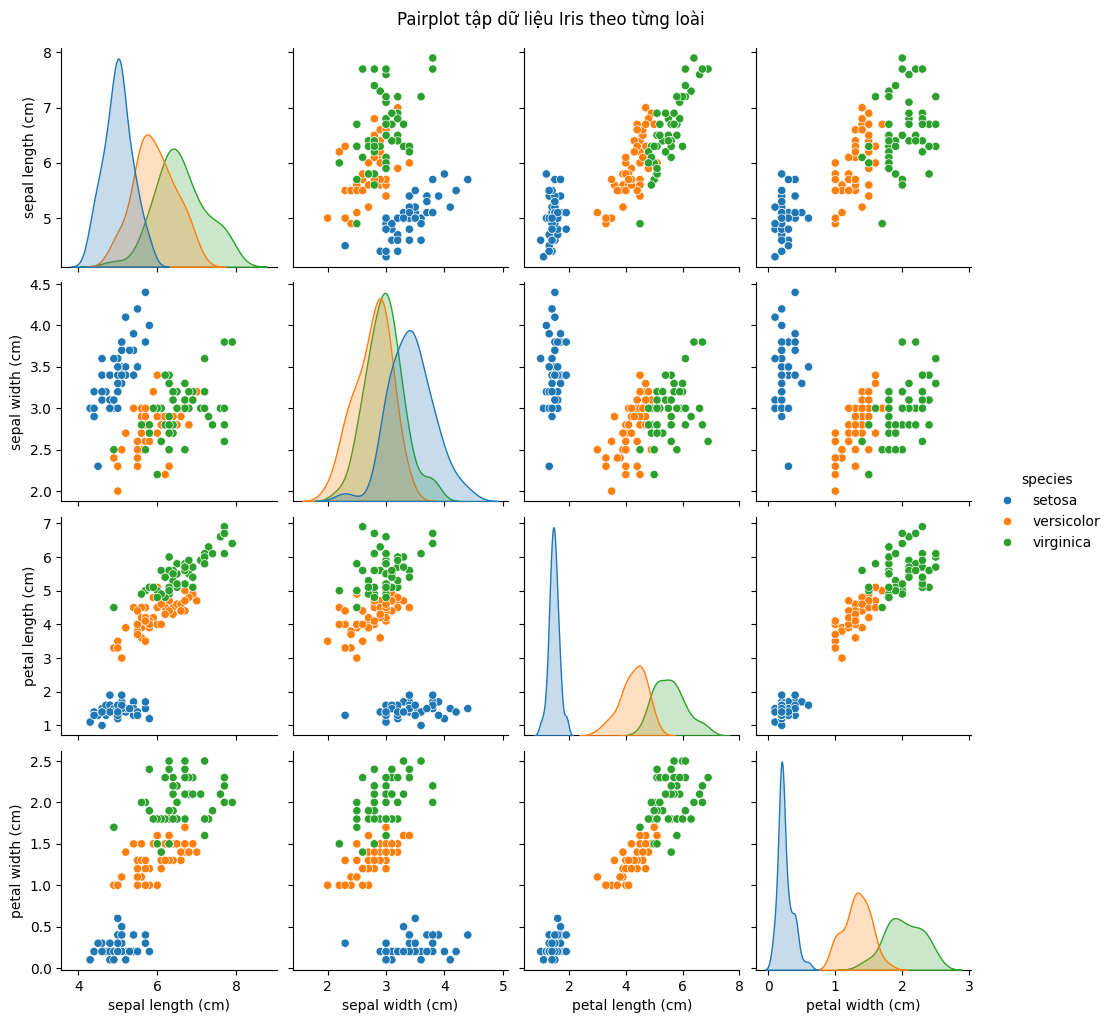

In [162]:
sns.pairplot(df, vars=num_cols, hue="species")
plt.suptitle('Pairplot tập dữ liệu Iris theo từng loài', y=1.02)
plt.show()

### Nhận xét
* Setosa tách biệt rõ khỏi hai loài còn lại trong hầu hết biểu đồ nhất là ở các biến petal length và petal width.

* Versicolor và virginica có chồng ở một số cặp biến nhưng vẫn có xu hướng phân tách tương đối.

* Nhìn vào biểu đồ scatter giữa petal pength vs Petal width, dữ liệu của cả 3 loài có thể vẽ được một đường tuyến tính có xu hướng đi lên. Điều này thể hiện cho hệ số tương quan 0.96 ở trên

# Phần 4 - Xác suất và định lý Bayes

### 1. Tính xác suất hậu nghiệm P(B|+)

In [164]:
P_B = 0.01 # Tỉ lệ mắc trong dân số
P_pos_given_B = 0.99 # P(+|B)
P_pos_given_notB = 0.05 # P(+|-B)

P_pos = P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print("P(B|+) =", round(P_B_given_pos, 4))

P(B|+) = 0.1667


### 2. Vẽ đồ thị P(B|+) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2

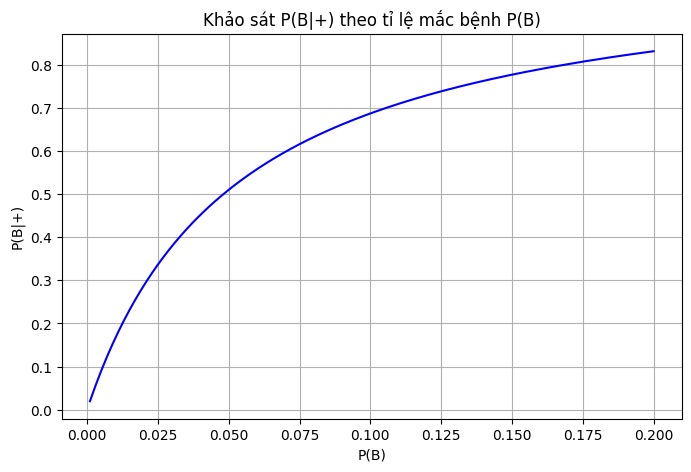

In [168]:
P_pos_given_B = 0.99
P_pos_given_notB = 0.05

P_B_values = np.linspace(0.001, 0.2, 200)
P_B_given_pos_values = []

for P_B in P_B_values:
    P_pos = P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B)
    P_B_given_pos = (P_pos_given_B * P_B) / P_pos
    P_B_given_pos_values.append(P_B_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(P_B_values, P_B_given_pos_values, color="blue")
plt.title("Khảo sát P(B|+) theo tỉ lệ mắc bệnh P(B)")
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.grid(True)
plt.show()

### Nhận xét


### Nhận xét

Kết quả chỉ ra rằng: Dù xét nghiệm chính xác đến 99%, một người nhận kết quả dương tính thì chỉ có 16.67% cơ hội thực sự mắc bệnh

Nguyên nhân là do căn bệnh quá hiếm (chỉ chiếm 1%) khiến nhóm người khỏe mạnh chiếm đại đa số (99%). Và khi đó, số ca dương tính giả từ nhóm người khỏe mạnh sẽ hoàn toàn lớn hơn số ca dương tính thật.

Ví dụ:
* Số người bệnh: 100 người -> Xét nghiệm đúng 99 ca dương tính thật.
* Số người lành: 9.900 người -> Bị báo nhầm 5% -> Ra 495 ca dương tính giả.

Tổng cộng có 594 người nhận kết quả dương tính (99 + 495), nhưng trong đó chỉ có 99 người thực sự bị bệnh. Lấy 99 chia cho 594 sẽ ra xấp xỉ 16.67%.

Vì vậy mà khi một hiện tượng quá hiếm, số ca dương tính giả từ quần thể lớn luôn áp đảo số ca dương tính thật